# Plastic zone at a Mode I crack tip

This notebook derives, symbolically, the first-order estimate of the
plastic-zone shape $r_p(\theta)$ ahead of a Mode I crack tip using the
von Mises yield criterion — the same problem as the exercise sheet
**"Plastic Zone at a Mode I Crack Tip"** handed out with this lecture
(with worked solution).

Run it however is easiest for you:

- **In a browser, nothing installed:**
  https://cfni-dtu.github.io/41526-notebooks/lab/index.html?path=lecture04/ModeI_plastic_zone.ipynb
- **Locally**, with any Jupyter install
  (`pip install numpy matplotlib sympy jupyterlab`, then `jupyter lab`).


In [1]:
# Works both in a normal Jupyter kernel (sympy already installed)
# and in JupyterLite's Pyodide kernel (sympy fetched on the fly via micropip).
try:
    import sympy as sp
except ImportError:
    import micropip
    await micropip.install("sympy")
    import sympy as sp

import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", message=".*width parameter as float.*")  # harmless mpl deprecation

sp.init_printing()


## Step 1 — Mode I near-tip stress field

Ahead of a Mode I crack tip, the leading-order (Williams) stress field is

$$
\sigma_{11} = \frac{K_I}{\sqrt{2\pi r}}\cos\frac{\theta}{2}
\Big[1-\sin\frac{\theta}{2}\sin\frac{3\theta}{2}\Big], \qquad
\sigma_{22} = \frac{K_I}{\sqrt{2\pi r}}\cos\frac{\theta}{2}
\Big[1+\sin\frac{\theta}{2}\sin\frac{3\theta}{2}\Big],
$$
$$
\sigma_{12} = \frac{K_I}{\sqrt{2\pi r}}\cos\frac{\theta}{2}
\sin\frac{\theta}{2}\cos\frac{3\theta}{2}, \qquad \sigma_{13}=\sigma_{23}=0,
$$

with $\sigma_{33}=0$ for plane stress and $\sigma_{33}=\nu(\sigma_{11}+\sigma_{22})$
for plane strain.


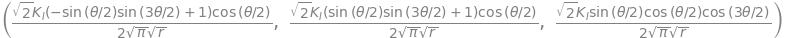

In [2]:
K, r, theta, sigma_Y, nu = sp.symbols('K_I r theta sigma_Y nu', positive=True, real=True)

A = K / sp.sqrt(2*sp.pi*r) * sp.cos(theta/2)

sigma11 = A * (1 - sp.sin(theta/2)*sp.sin(3*theta/2))
sigma22 = A * (1 + sp.sin(theta/2)*sp.sin(3*theta/2))
sigma12 = A * sp.sin(theta/2)*sp.cos(3*theta/2)

sigma11, sigma22, sigma12


## Step 2 — von Mises equivalent stress

With $\sigma_{13}=\sigma_{23}=0$, the von Mises equivalent stress for this
plane problem is

$$
\sigma_e^2 = \sigma_{11}^2+\sigma_{22}^2+\sigma_{33}^2
-\sigma_{11}\sigma_{22}-\sigma_{22}\sigma_{33}-\sigma_{11}\sigma_{33}+3\sigma_{12}^2 .
$$

We evaluate this for $\sigma_{33}=0$ (plane stress) and
$\sigma_{33}=\nu(\sigma_{11}+\sigma_{22})$ (plane strain).


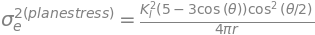

In [3]:
def sigma_e2(sigma33):
    return sp.simplify(
        sigma11**2 + sigma22**2 + sigma33**2
        - sigma11*sigma22 - sigma22*sigma33 - sigma11*sigma33
        + 3*sigma12**2
    )

sigma_e2_stress = sigma_e2(0)
sigma_e2_strain = sigma_e2(nu*(sigma11 + sigma22))

display(sp.Eq(sp.Symbol('sigma_e^2 (plane stress)'), sigma_e2_stress))
display(sp.Eq(sp.Symbol('sigma_e^2 (plane strain)'), sigma_e2_strain))


## Step 3 — Solve $\sigma_e=\sigma_Y$ for $r=r_p(\theta)$

This is the plastic-zone boundary: the locus where the *elastic* K-field
first reaches yield.


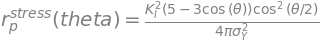

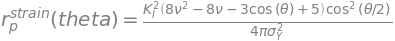

In [4]:
rp_stress = sp.solve(sp.Eq(sigma_e2_stress, sigma_Y**2), r)[0]
rp_strain = sp.solve(sp.Eq(sigma_e2_strain, sigma_Y**2), r)[0]

rp_stress = sp.simplify(rp_stress)
rp_strain = sp.simplify(rp_strain)

display(sp.Eq(sp.Symbol('r_p^{stress}(theta)'), rp_stress))
display(sp.Eq(sp.Symbol('r_p^{strain}(theta)'), rp_strain))


## Step 4 — Plot the shapes

We plot $r_p(\theta)$ in polar form, normalised by $(K/\sigma_Y)^2$ — the
same normalisation used for the plots in the lecture slides — for plane
stress and a few values of $\nu$ in plane strain, alongside the **Mode III**
result from the Mode III plastic zone notebook:

$$
r_p = \frac{3}{2\pi}\left(\frac{K_{III}}{\sigma_Y}\right)^2 \quad \text{(circle, independent of } \theta \text{)}.
$$


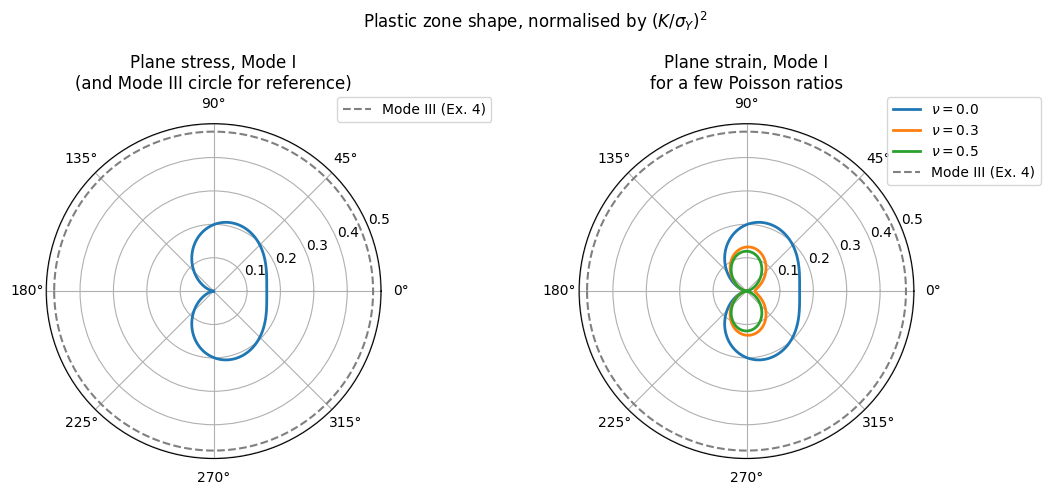

In [5]:
rp_stress_f = sp.lambdify(theta, rp_stress.subs({K: 1, sigma_Y: 1}), 'numpy')
rp_strain_f = sp.lambdify((theta, nu), rp_strain.subs({K: 1, sigma_Y: 1}), 'numpy')

th = np.linspace(-np.pi, np.pi, 400)
r_mode3 = np.full_like(th, 3/(2*np.pi))  # K_III/sigma_Y = 1

fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(11, 5))

ax = axes[0]
ax.plot(th, rp_stress_f(th), lw=2, color='tab:blue')
ax.plot(th, r_mode3, lw=1.5, ls='--', color='gray', label='Mode III')
ax.set_title('Plane stress, Mode I\n(and Mode III circle for reference)')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

ax = axes[1]
for nu_val, style in zip([0.0, 0.3, 0.5], ['-', '-', '-']):
    ax.plot(th, rp_strain_f(th, nu_val), lw=2, label=fr'$\nu={nu_val}$')
ax.plot(th, r_mode3, lw=1.5, ls='--', color='gray', label='Mode III')
ax.set_title('Plane strain, Mode I\nfor a few Poisson ratios')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))

fig.suptitle(r'Plastic zone shape, normalised by $(K/\sigma_Y)^2$')
fig.tight_layout()
plt.show()


## Takeaways

- Unlike the **Mode III** zone, which is an exact circle
  because the two non-zero shear stresses combine into a $\theta$-independent
  von Mises stress, the **Mode I** zone is lobed: a single forward lobe in
  plane stress, and a narrower "dog-bone" shape in plane strain.
- Increasing $\nu$ shrinks the plane-strain zone directly ahead of the tip
  ($\theta=0$) by a factor $(1-2\nu)^2$, pushing the lobes further to the
  sides — the higher triaxiality there suppresses yielding.
- This is only a **first-order estimate**: it assumes the elastic $K$-field
  is still valid right up to the elastic-plastic boundary. Stress
  redistribution due to plasticity (Irwin's correction) enlarges the actual
  zone beyond $r_p(\theta)$ found here.
